### Training a classifier based on decision trees

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create a Decision Tree Classifier
decisiontree = DecisionTreeClassifier(random_state=0)

# Train the model
model = decisiontree.fit(features, target)

# Create a new observation for prediction
observation = [[5, 4, 3, 2]]

# Predict the class of the observation
model.predict(observation)

# Predict the probability of each class for the observation
model.predict_proba(observation)

array([[0., 1., 0.]])

In [32]:
# Create a Decision Tree Classifier with entropy criterion
decisiontree_entropy = DecisionTreeClassifier(criterion="entropy", random_state=0)

# Train the model
model_entropy = decisiontree_entropy.fit(features, target)

# Predict the class of the observation
model_entropy.predict(observation)

# Predict the probability of each class for the observation
model_entropy.predict_proba(observation)

array([[0., 1., 0.]])

### Learning Perspectives Using Decision Trees

In [33]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import datasets

# Load the diabetes dataset
diabetes = datasets.load_diabetes()
features = diabetes.data
target = diabetes.target

# Create a Decision Tree Regressor
decisiontree = DecisionTreeRegressor(random_state=0)

# Train the model
model = decisiontree.fit(features, target)

# Create a new observation for prediction
observation = [features[0]]

# Predict the value of the observation
model.predict(observation)


array([151.])

In [34]:
# Create a Decision Tree Regressor with mean absolute error criterion
decisiontree_mae = DecisionTreeRegressor(criterion="absolute_error",
random_state=0)

# Train the model
model_mae = decisiontree_mae.fit(features, target)

model_mae.predict(observation)

array([151.])

### Visualization of the decision tree model

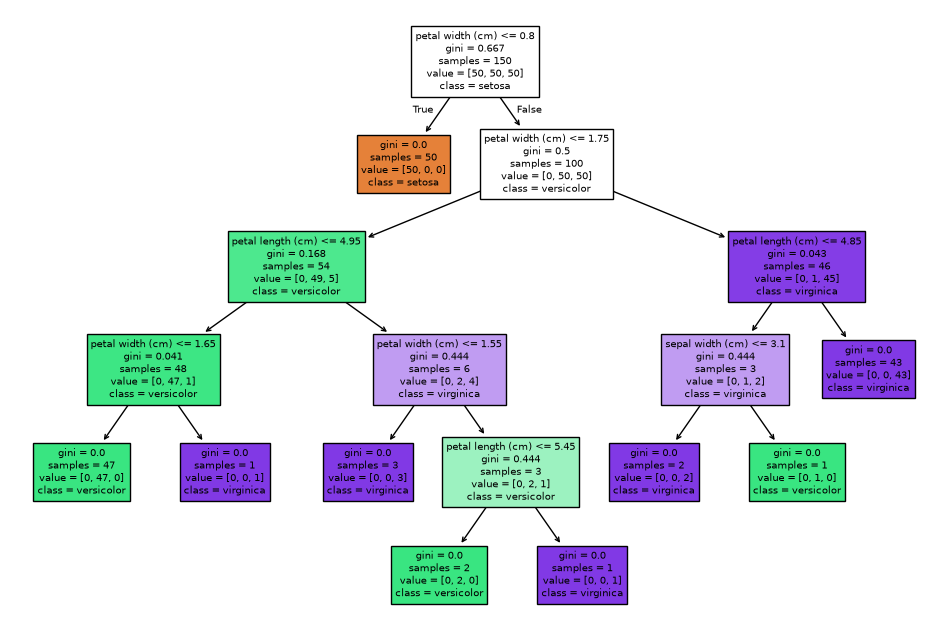

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets
from sklearn import tree
import matplotlib.pyplot as plt

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create a Decision Tree Classifier
decisiontree = DecisionTreeClassifier(random_state=0)

# Train the model
model = decisiontree.fit(features, target)

# Plot the decision tree with matplotlib
plt.figure(figsize=(12, 8))
tree.plot_tree(
    decisiontree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
)
plt.show()

### Training a classifier based on a random forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create a Random Forest Classifier
randomforest = RandomForestClassifier(random_state=0, n_jobs=-1)

# Train the model
model = randomforest.fit(features, target)

# Create a new observation for prediction
observation = [[5, 4, 3, 2]]

# Predict the class of the observation
model.predict(observation)

# Create a Random Forest Classifier using the entropy criterion
randomforest_entropy = RandomForestClassifier(
    criterion="entropy", random_state=0, n_jobs=-1)

# Train the model
model_entropy = randomforest_entropy.fit(features, target)



### Training a regressor using random forest

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn import datasets

# Load the diabetes dataset
diabetes = datasets.load_diabetes()
features = diabetes.data
target = diabetes.target

# Create a Random Forest Regressor
randomforest = RandomForestRegressor(random_state=0, n_jobs=-1)

# Train the model
model = randomforest.fit(features, target)

### Evaluating Random Forest Models using the Out-of-Bag Method

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create a Random Forest Classifier
randomforest = RandomForestClassifier(
    random_state=0, 
    n_estimators=1000, 
    oob_score=True, 
    n_jobs=-1)

# Train the model
model = randomforest.fit(features, target)

print(randomforest.oob_score_)

0.9533333333333334


### Identifying Key Features in Random Forest Models

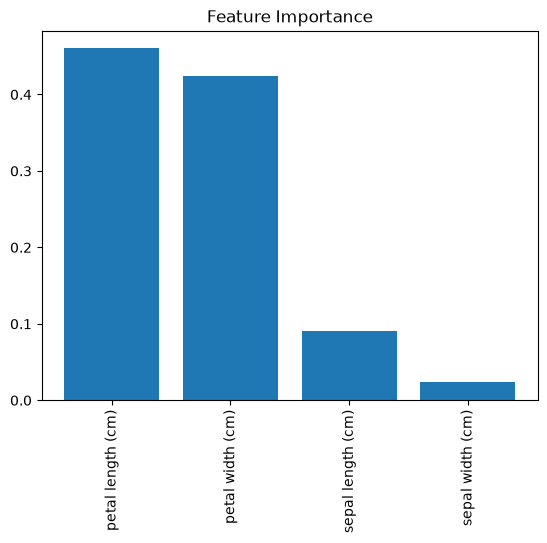

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create a Random Forest Classifier
randomforest = RandomForestClassifier(random_state=0, n_jobs=-1)

# Train the model
model = randomforest.fit(features, target)

# Calculate feature importances
importances = model.feature_importances_

# Sort the features by importance
indices = np.argsort(importances)[::-1]

# Regroup the feature names based on the sorted indices
names = [iris.feature_names[i] for i in indices]

# Create a bar chart of feature importances
plt. figure()

# Create the title of the chart
plt.title("Feature Importance")

# Add columns
plt.bar(range(features.shape[1]), importances[indices])

# Add feature names on the x-axis
plt.xticks(range(features.shape[1]), names, rotation=90)

# Show the chart
plt.show()

In [49]:
# Print the feature importances
print(model.feature_importances_)

[0.09090795 0.02453104 0.46044474 0.42411627]


### Key feature selection in random forest models

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
from sklearn.feature_selection import SelectFromModel

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create a Random Forest Classifier
randomforest = RandomForestClassifier(random_state=0, n_jobs=-1)

# Create a SelectFromModel object with a threshold of 0.3
selector = SelectFromModel(randomforest, threshold=0.3)

# Fit the selector to the data and transform the features
features_important = selector.fit_transform(features, target)

# Train the model on the selected features
model = randomforest.fit(features_important, target)


### Managing unbalanced classes

In [59]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Remove the first 40 samples from the features and target arrays
features = features[40:,:]
target = target[40:]

# Create a binary classification problem by converting the target values to 0 and 1
target = np.where((target == 0), 0, 1)

# Создамь обьекм классификации мемодом случайного леса
randomforest = RandomForestClassifier(
    n_jobs=-1, 
    class_weight="balanced", 
    random_state=0)

# Train the model on the features and target
model = randomforest.fit(features, target)

### Tree size control

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create a Decision Tree Classifier with specific hyperparameters
decisiontree = DecisionTreeClassifier(
    random_state=0,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0,
    max_leaf_nodes=None,
    min_impurity_decrease=0)

# Train the model on the features and target
model = decisiontree.fit(features, target)

### Improving quality through boosting

In [62]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn import datasets

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create an AdaBoost Classifier
adaboost = AdaBoostClassifier(random_state=0)

# Train the model on the features and target
model = adaboost.fit(features, target)

### Training a model based on the XGBoost algorithm

In [70]:
import xgboost as xgb
from sklearn import datasets, preprocessing
from sklearn.metrics import classification_report
from numpy import argmax

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create a DMatrix for XGBoost
xgb_train = xgb.DMatrix(features, label=target)

param = {
    'objective': 'multi:softprob',
    'num_class': 3
}

# Train the XGBoost model
gbm = xgb.train(param, xgb_train)

# Get predictions
predictions = argmax(gbm.predict(xgb_train), axis=1)

# Create a classification report
print(classification_report(target, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      0.96      0.98        50
           2       0.96      1.00      0.98        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



### Improving Performance with LightGBM

In [75]:
import lightgbm as lgb
from sklearn import datasets, preprocessing
from sklearn.metrics import classification_report
from numpy import argmax

# Load the iris dataset
iris = datasets.load_iris()
features = iris.data
target = iris.target

# Create a LightGBM Dataset
lgb_train = lgb.Dataset(features, target)

# Define parameters for LightGBM
params = {
    'objective': 'multiclass',
    'num_class': 3,
    'verbose': -1
}

# Train the LightGBM model
gbm = lgb.train(params, lgb_train)

# Get predictions
predictions = argmax(gbm.predict(features), axis=1)

# Create classification report
print(classification_report(target, predictions))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150

